<a href="https://colab.research.google.com/github/sankalan-sil/AI-Lab/blob/main/AI_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1: BFS and DFS Traversal of a Graph:
Problem Statement:
A small graph, shaped like a tree with six nodes (A, B, C, D, E, F) and node A as the root, is given below. Write a Python program that:
1. Stores the graph using an adjacency list (a Python dictionary).
2. Performs a BFS traversal starting from node A.
3. Performs a DFS traversal starting from node A.
4. Prints both traversal orders, and draws two separate tree diagrams — one showing the order in which BFS visits the nodes, and another showing the order in which DFS visits the nodes.

In [ ]:
!pip install networkx matplotlib


BFS Traversal: A -> B -> C -> D -> E -> F
DFS Traversal: A -> B -> D -> E -> C -> F


/tmp/ipykernel_872/3949389382.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


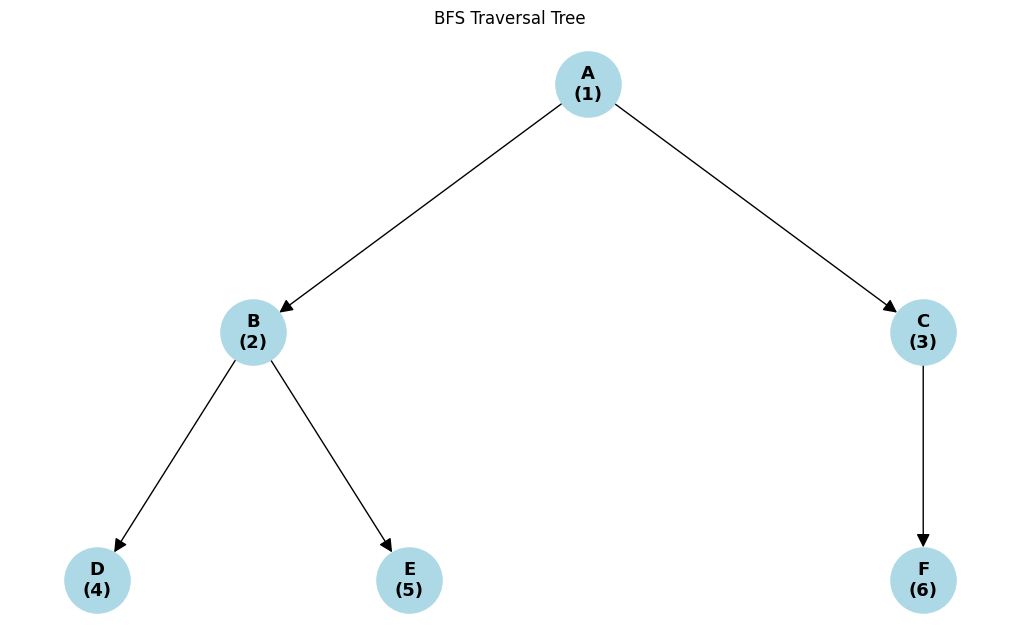

/tmp/ipykernel_872/3949389382.py:187: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


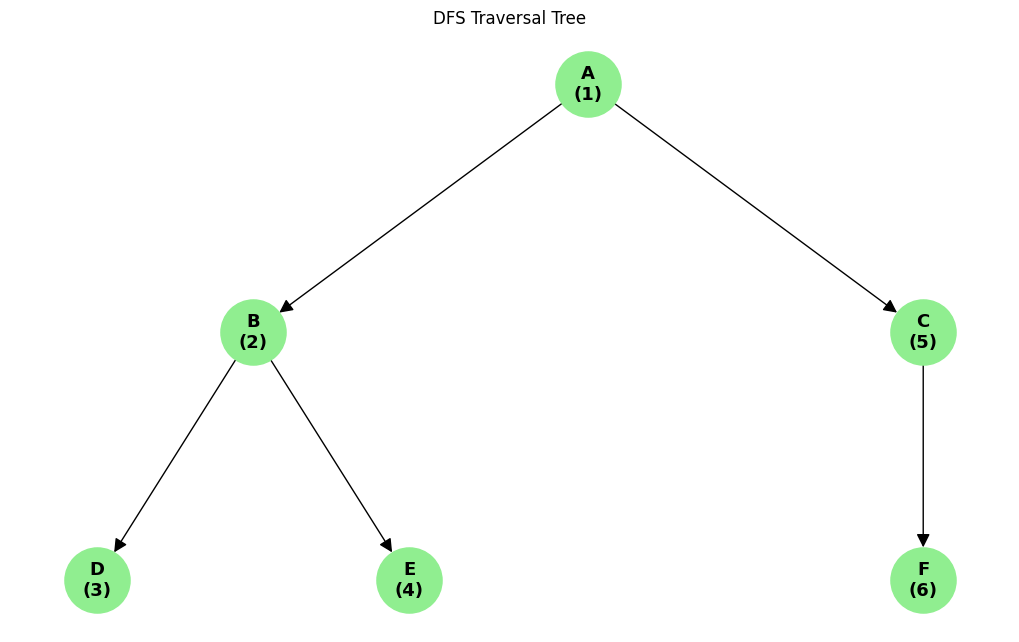

In [1]:

import networkx as nx
import matplotlib.pyplot as plt
from collections import deque


graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': [],
    'F': []
}


# ---------------- BFS ----------------

def bfs(graph, start):
    visited = set()
    queue = deque([start])
    traversal = []

    visited.add(start)

    while queue:
        node = queue.popleft()
        traversal.append(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)

    return traversal


# ---------------- DFS ----------------

def dfs(graph, start):
    visited = set()
    traversal = []

    def dfs_recursive(node):
        visited.add(node)
        traversal.append(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                dfs_recursive(neighbour)

    dfs_recursive(start)

    return traversal


bfs_order = bfs(graph, 'A')
dfs_order = dfs(graph, 'A')


print("BFS Traversal:", " -> ".join(bfs_order))
print("DFS Traversal:", " -> ".join(dfs_order))


# ---------------- BFS TREE ----------------

def draw_bfs_tree(graph, traversal):

    G = nx.DiGraph()

    visited = set()
    queue = deque(['A'])
    visited.add('A')

    while queue:
        node = queue.popleft()

        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)
                G.add_edge(node, neighbour)

    # Positions
    pos = {
        'A': (0, 2),
        'B': (-1.5, 1),
        'C': (1.5, 1),
        'D': (-2.2, 0),
        'E': (-0.8, 0),
        'F': (1.5, 0)
    }

    plt.figure(figsize=(10, 6))

    # IMPORTANT: with_labels=False
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_size=2200,
        node_color='lightblue',
        font_size=14,
        font_weight='bold',
        arrows=True,
        arrowsize=20
    )

    # Custom labels with traversal number
    labels = {
        node: f"{node}\n({traversal.index(node) + 1})"
        for node in G.nodes()
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=13,
        font_weight='bold'
    )

    plt.title("BFS Traversal Tree")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ---------------- DFS TREE ----------------

def draw_dfs_tree(graph, traversal):

    G = nx.DiGraph()

    visited = set()

    def dfs_tree(node):
        visited.add(node)

        for neighbour in graph[node]:
            if neighbour not in visited:
                G.add_edge(node, neighbour)
                dfs_tree(neighbour)

    dfs_tree('A')

    # Positions
    pos = {
        'A': (0, 2),
        'B': (-1.5, 1),
        'D': (-2.2, 0),
        'E': (-0.8, 0),
        'C': (1.5, 1),
        'F': (1.5, 0)
    }

    plt.figure(figsize=(10, 6))

    # IMPORTANT: with_labels=False
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_size=2200,
        node_color='lightgreen',
        font_size=14,
        font_weight='bold',
        arrows=True,
        arrowsize=20
    )

    # Custom labels with traversal number
    labels = {
        node: f"{node}\n({traversal.index(node) + 1})"
        for node in G.nodes()
    }

    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        font_size=13,
        font_weight='bold'
    )

    plt.title("DFS Traversal Tree")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# ---------------- DISPLAY ----------------

draw_bfs_tree(graph, bfs_order)
draw_dfs_tree(graph, dfs_order)